In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Loading the dataset
df =pd.read_csv('/seasonal_agriculture_performance_dataset.csv')

In [6]:
#review top 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [7]:
df.tail() #Last five rows.

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [8]:
#data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
#stastical info
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [10]:
from os import dup
#data quality check
duplicate_count = df.duplicated().sum()
print('Duplicate Rows',duplicate_count)

Duplicate Rows 0


In [14]:
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]
missing.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %


In [12]:
# Categorical columns: missing means we do not know the category.
categorical_columns = [
    'Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha',
]

for col in categorical_columns:
    df[col] = df[col].fillna('Unknown')

In [21]:
#Analyze
season_counts = df['Season'].value_counts()
season_counts

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [23]:
crop_counts = df['Crop'].value_counts()
crop_counts


,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [28]:
avg_temperature=df['Avg_Temperature_C'].value_counts()
avg_temperature

,count
Avg_Temperature_C,
27.9,54
28.6,47
29.0,45
27.7,44
29.2,43
...,...
36.3,1
16.7,1
35.7,1


In [35]:
soil_ph = df['Soil_pH'].value_counts()
soil_ph

,count
Soil_pH,
5.20,44
6.52,38
6.80,37
6.81,36
6.62,31
...,...
8.12,1
5.22,1
8.29,1


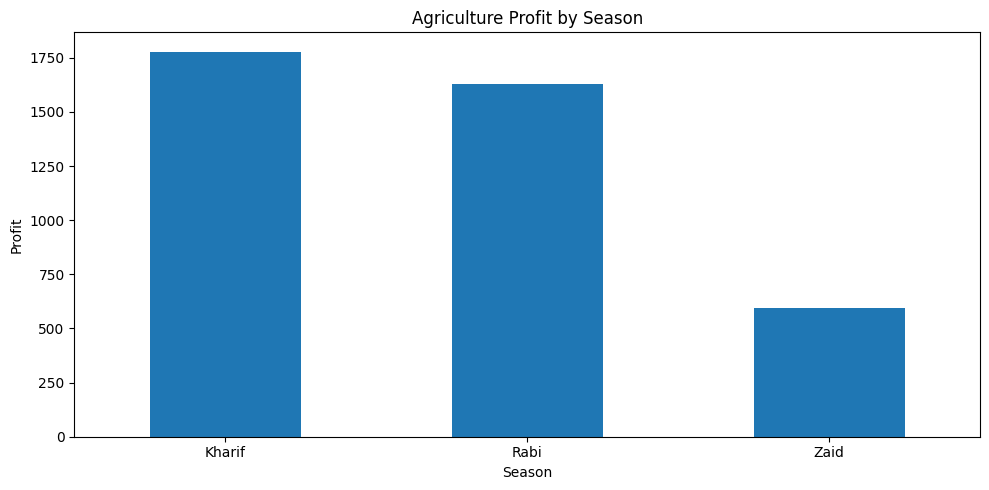

In [34]:
# Chart 1: Profit by Various Seasons
plt.figure(figsize=(10, 5))
season_counts.plot(kind='bar')
plt.title('Agriculture Profit by Season')
plt.xlabel('Season')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

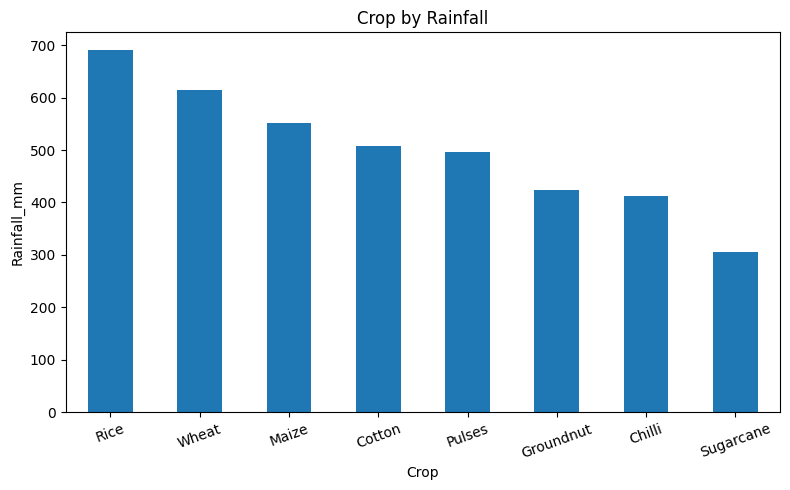

In [24]:
# Chart 2: Crop Grown By Rainfall
plt.figure(figsize=(8, 5))
crop_counts.plot(kind='bar')
plt.title('Crop by Rainfall')
plt.xlabel('Crop')
plt.ylabel('Rainfall_mm')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

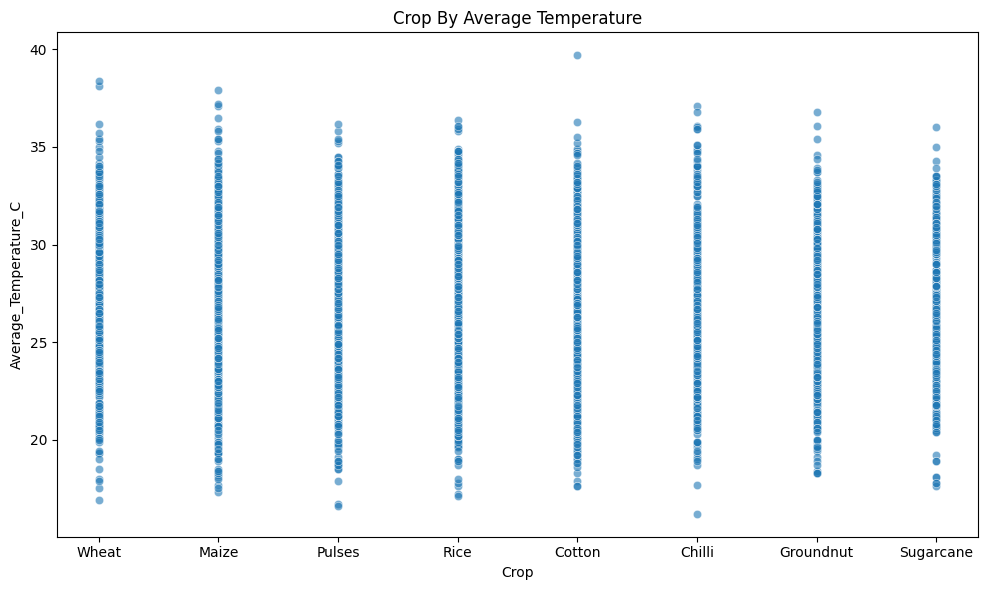

In [31]:
# Chart 3: Crop Grown By Average Temperature
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Crop', y='Avg_Temperature_C', data=df, alpha=0.6)
plt.title('Crop By Average Temperature')
plt.xlabel('Crop')
plt.ylabel('Average_Temperature_C')
plt.tight_layout()
plt.show()

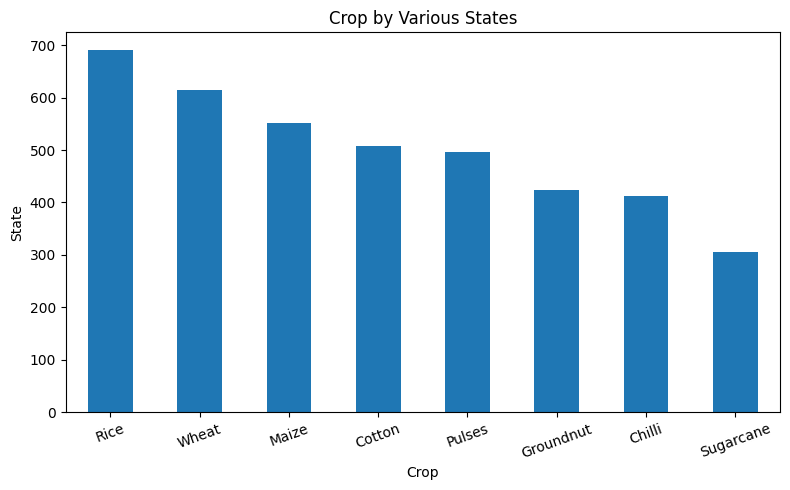

In [32]:
# Chart 4: Crop Grown By Various States
plt.figure(figsize=(8, 5))
crop_counts.plot(kind='bar')
plt.title('Crop by Various States')
plt.xlabel('Crop')
plt.ylabel('State')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

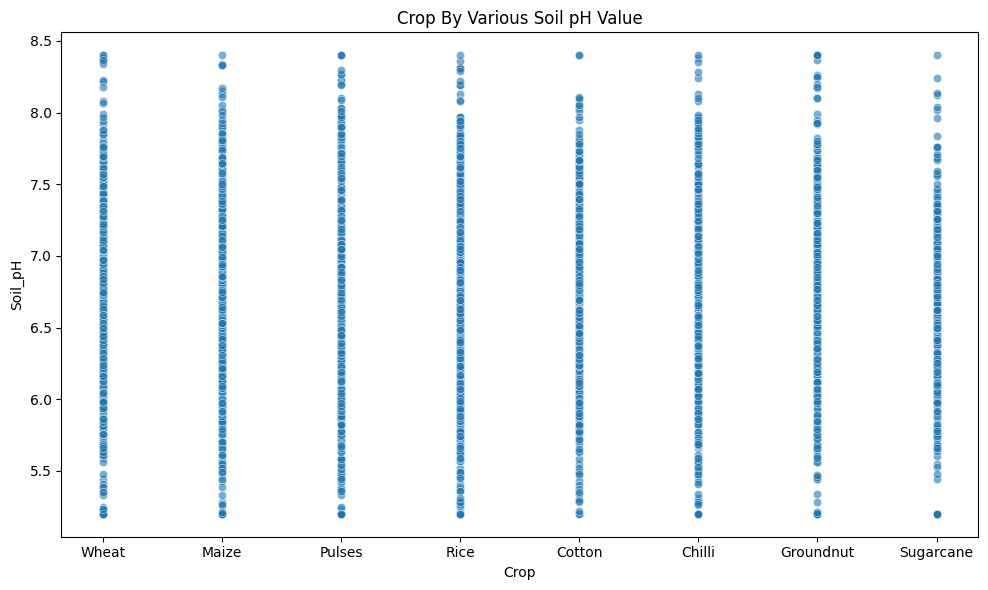

In [38]:
# Chart 5: Crop Grown By Various Soil pH Value
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Crop', y='Soil_pH', data=df, alpha=0.6)
plt.title('Crop By Various Soil pH Value')
plt.xlabel('Crop')
plt.ylabel('Soil_pH')
plt.tight_layout()
plt.show()